# Notebook 2: XGBoost Forecasting Baseline
Fastest to train, strong benchmark. Uses engineered lag + time features.

In [1]:
import sys; sys.path.append('../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from preprocessing import preprocess
from evaluate import report
from visualize import plot_forecast
import joblib

plt.rcParams['figure.figsize'] = (16, 5)

In [2]:
df = preprocess('../data/energy_consumption.csv')
print(df.shape)
df.head()

(52440, 27)


C:\Users\mohin\OneDrive\Desktop\AI Powered Energy Consumption Forcasting\notebooks\../src\preprocessing.py:13: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_idx = pd.date_range(start=df.index.min(), end=df.index.max(), freq='H')


,consumption_mwh,hour,day_of_week,day_of_year,week,month,year,quarter,is_weekend,hour_sin,...,lag_3h,lag_6h,lag_12h,lag_24h,lag_48h,lag_168h,roll_mean_24h,roll_std_24h,roll_mean_168h,roll_std_168h
timestamp,,,,,,,,,,,,,,,,,,,,,
2016-01-07 21:00:00,14074.0,21,3,7,1,1,2016,1,0,-0.707107,...,14829.0,15105.0,14791.0,13672.0,13197.0,10800.0,14266.166667,791.217755,12246.821429,1446.774100
2016-01-07 22:00:00,13643.0,22,3,7,1,1,2016,1,0,-0.500000,...,14342.0,15043.0,14747.0,13285.0,12765.0,10431.0,14282.916667,782.297281,12266.309524,1449.217050
2016-01-07 23:00:00,13369.0,23,3,7,1,1,2016,1,0,-0.258819,...,14303.0,14982.0,14670.0,13011.0,12335.0,10005.0,14297.833333,765.678538,12285.428571,1446.043384
2016-01-08 00:00:00,13142.0,0,4,8,1,1,2016,1,0,0.000000,...,14074.0,14829.0,14647.0,12821.0,12167.0,9722.0,14312.750000,742.660157,12305.452381,1437.542684
2016-01-08 01:00:00,13111.0,1,4,8,1,1,2016,1,0,0.258819,...,13643.0,14342.0,14716.0,12821.0,12023.0,9599.0,14326.125000,717.076147,12325.809524,1424.898992


In [3]:
# Train/val/test split — last 30 days = test, prior 30 days = val
TARGET = 'consumption_mwh'
FEATURES = [c for c in df.columns if c != TARGET]

test_cutoff = df.index[-24*30]
val_cutoff  = df.index[-24*60]

train = df[df.index < val_cutoff]
val   = df[(df.index >= val_cutoff) & (df.index < test_cutoff)]
test  = df[df.index >= test_cutoff]

print(f'Train: {len(train):,} | Val: {len(val):,} | Test: {len(test):,}')

Train: 51,000 | Val: 720 | Test: 720


In [4]:
model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=50,
    random_state=42,
    tree_method='hist'
)

model.fit(
    train[FEATURES], train[TARGET],
    eval_set=[(val[FEATURES], val[TARGET])],
    verbose=100
)

joblib.dump(model, '../models/xgboost_model.pkl')
print('Model saved.')

[0]	validation_0-rmse:1472.04446


[100]	validation_0-rmse:107.39997


[200]	validation_0-rmse:92.74770


[300]	validation_0-rmse:88.94116


[400]	validation_0-rmse:87.85016


[500]	validation_0-rmse:86.00140


[600]	validation_0-rmse:85.53560


[683]	validation_0-rmse:85.98938


Model saved.



  XGBoost
  MAE     : 87.0738
  RMSE    : 115.1943
  MAPE    : 0.7202
  SMAPE   : 0.7213


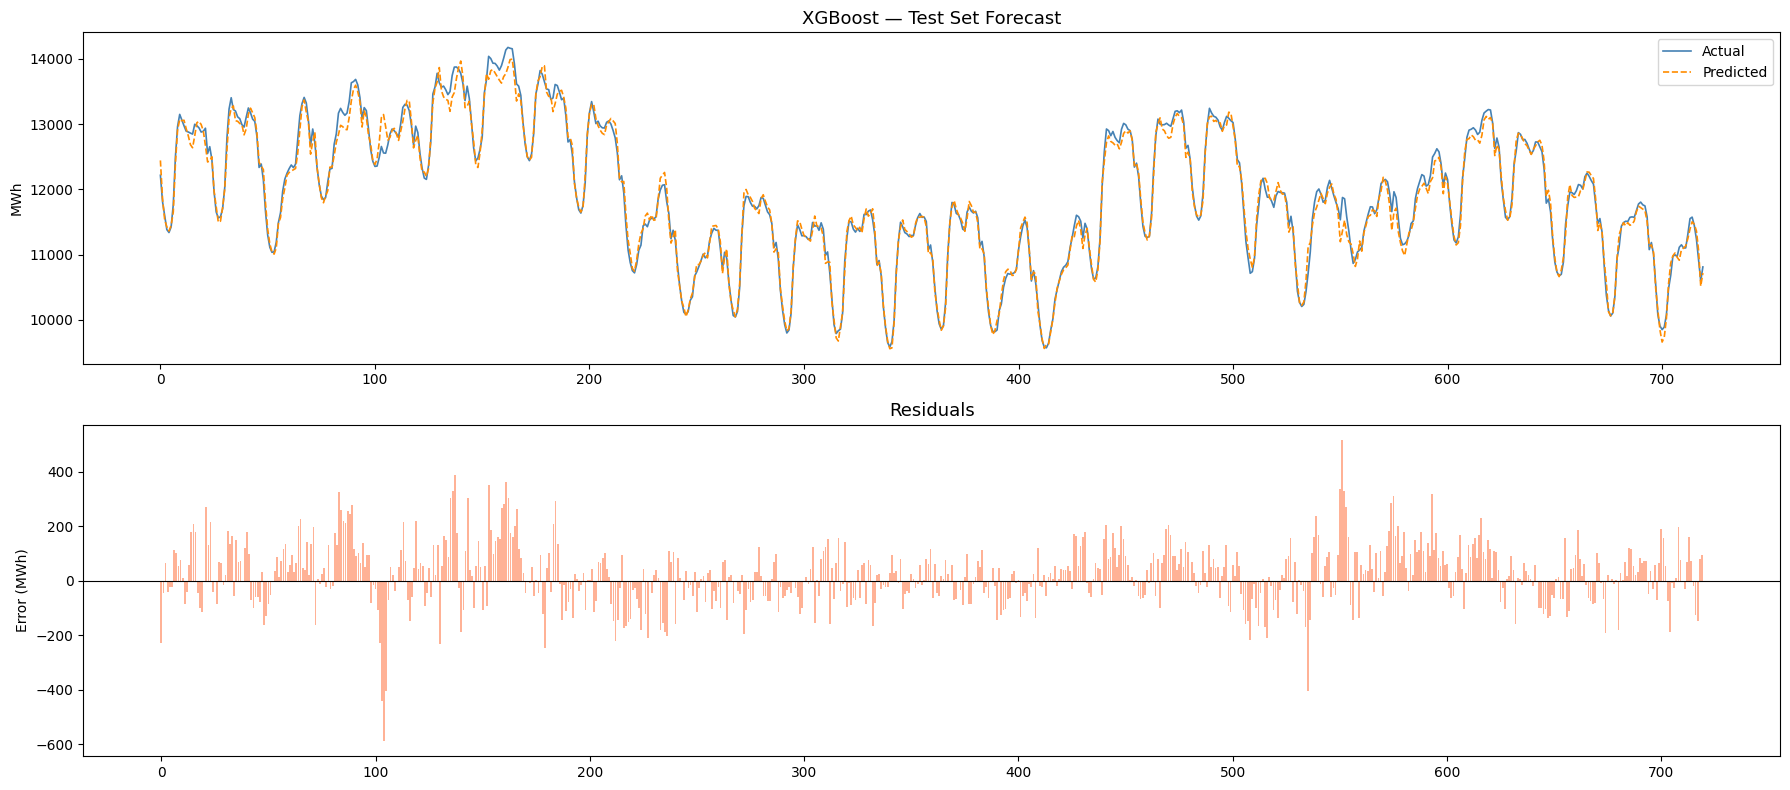

In [5]:
preds = model.predict(test[FEATURES])
metrics = report(test[TARGET], preds, 'XGBoost')
plot_forecast(test[TARGET], preds, title='XGBoost — Test Set Forecast',
              save_path='../outputs/figures/xgb_forecast.png')

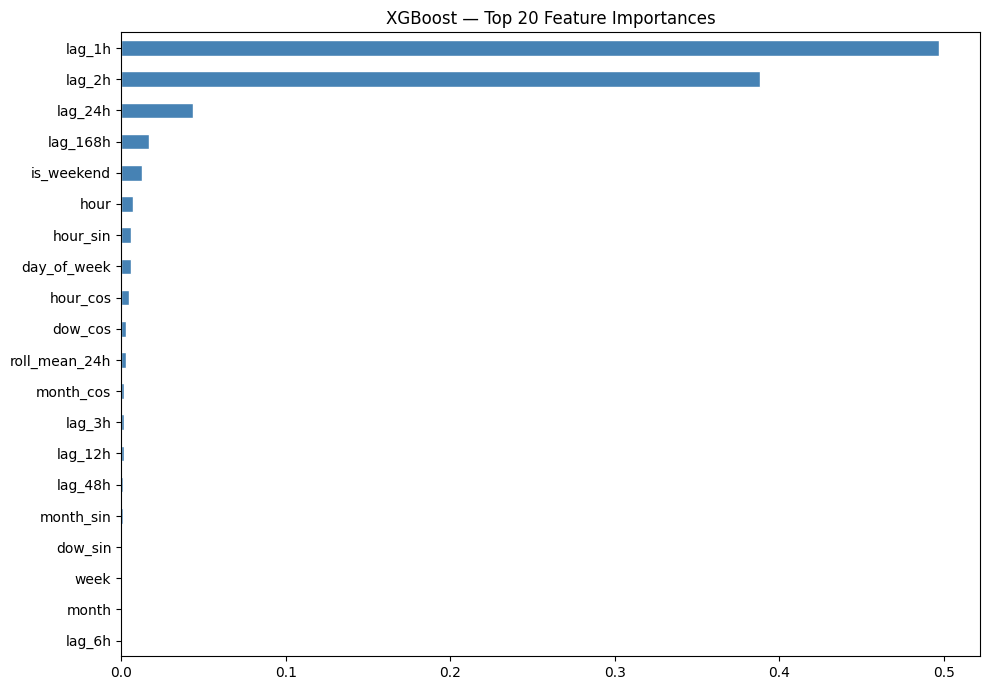

In [6]:
# Feature importance
fi = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=False).head(20)
fi.plot(kind='barh', figsize=(10, 7), color='steelblue', edgecolor='white')
plt.gca().invert_yaxis()
plt.title('XGBoost — Top 20 Feature Importances')
plt.tight_layout()
plt.savefig('../outputs/figures/xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()